In [ ]:
import os

os.makedirs("data/processed", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

# AI-Powered Loan Risk Intelligence System
## Feature Engineering & Risk Segmentation

This notebook covers the **Feature Engineering and Risk Segmentation** phase of the **AI-Powered Loan Risk Intelligence System**. Building on the insights from the Exploratory Data Analysis (EDA) phase, we will transform raw borrower attributes into sophisticated, business-ready risk intelligence features. 

These features will categorize borrower characteristics and apply structured business rules to segment risk levels, creating a model-ready dataset suitable for predictive modeling and risk profiling.

### Objectives
1. **Load raw data**: Load the raw dataset (`data/raw/Loan_default.xlsx`) containing borrower profile information.
2. **Age Segmentation**: Discretize age into standard generational brackets (`AgeGroup`).
3. **Income Segmentation**: Segment annual income using quartile-based thresholds (`IncomeGroup`).
4. **Credit Risk Banding**: Group credit scores into FICO-style risk bands (`CreditRiskBand`).
5. **Debt Leverage (Loan-to-Income)**: Compute the borrower's loan amount as a ratio of their annual income (`LoanToIncomeRatio`).
6. **Loan Size Classification**: Categorize loan amounts using quartile-based categories (`LoanSizeCategory`).
7. **Risk Tiering**: Construct a unified `RiskTier` using logic-based business rules combining credit score and leverage indicators.
8. **Segmentation Visualizations**: Generate visualizations highlighting historical default rates across engineered categories and the leverage distribution.
9. **Save Processed Dataset**: Export the transformed, model-ready dataset to the processed folder.
10. **Business Insights**: Document key takeaways, risk drivers, and portfolio impact.

---

### 1. Setup and Environment Configuration
We import standard scientific and visualization libraries. To maintain visual consistency with the EDA phase, we apply identical styles and configure a unified color palette for all charts.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure styling for professional aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 100,
    'font.family': 'sans-serif'
})

# Define premium, cohesive color palette
PRIMARY_COLOR = '#1E3A8A'  # Deep Navy
SECONDARY_COLOR = '#0D9488'  # Teal
ALERT_COLOR = '#E11D48'  # Rose/Red
NEUTRAL_DARK = '#1E293B'  # Charcoal
NEUTRAL_LIGHT = '#F8FAFC'  # Slate Light

print("Setup completed successfully. Libraries loaded and styles configured.")

C:\Users\Owner\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Owner\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Setup completed successfully. Libraries loaded and styles configured.


### 2. Loading the Dataset
We read the raw Excel dataset from `data/raw/Loan_default.xlsx` using `pandas` and inspect its shape and first few rows to confirm the data layout.

In [2]:
# Load dataset using pandas from relative path
file_path = '../data/raw/Loan_default.xlsx'
df = pd.read_excel(file_path)
print(f"Dataset loaded successfully from: {file_path}")
print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns\n")
display(df.head())

Dataset loaded successfully from: ../data/raw/Loan_default.xlsx
Dataset Shape: 255,347 rows, 7 columns



,Age,Income,LoanAmount,CreditScore,LoanTerm,EmploymentType,Default
0,56,85994,50587,520,36,Full-time,0
1,69,50432,124440,458,60,Full-time,0
2,46,84208,129188,451,24,Unemployed,1
3,32,31713,44799,743,24,Full-time,0
4,60,20437,9139,633,48,Unemployed,0


### 3. Feature Engineering: Creating AgeGroup
Age is a continuous variable. Discretizing age into generational brackets helps capture lifecycle risk patterns (e.g., young borrowers early in their career versus established, older borrowers). We define the groups as follows:
- **18-25**
- **26-35**
- **36-45**
- **46-55**
- **56+**

In [3]:
# Discretize age into generational brackets
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 45, 55, np.inf],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)

print("AgeGroup value counts:")
print(df['AgeGroup'].value_counts(dropna=False))

AgeGroup value counts:
AgeGroup
56+      68555
26-35    49408
36-45    49220
46-55    49148
18-25    39016
Name: count, dtype: int64


### 4. Feature Engineering: Creating IncomeGroup
Using quartile boundaries (25th, 50th, 75th percentiles), we segment borrower income into four equally distributed categories: Low Income, Medium Income, High Income, and Very High Income. This accounts for relative income disparities within the target population.

In [4]:
# Bin annual income into quartile-based groups
df['IncomeGroup'] = pd.qcut(
    df['Income'],
    q=4,
    labels=['Low Income', 'Medium Income', 'High Income', 'Very High Income']
)

print("IncomeGroup value counts:")
print(df['IncomeGroup'].value_counts(dropna=False))

IncomeGroup value counts:
IncomeGroup
High Income         63839
Low Income          63837
Medium Income       63837
Very High Income    63834
Name: count, dtype: int64


### 5. Feature Engineering: Creating CreditRiskBand
We map continuous FICO credit scores into creditworthiness bands. These bands mimic real-world financial decision-making grids, allowing for quick risk classification:
- **Poor**: 300 to 579
- **Fair**: 580 to 669
- **Good**: 670 to 739
- **Excellent**: 740 and above

In [5]:
# Map credit scores to risk bands
df['CreditRiskBand'] = pd.cut(
    df['CreditScore'],
    bins=[299, 579, 669, 739, np.inf],
    labels=['Poor', 'Fair', 'Good', 'Excellent']
)

print("CreditRiskBand value counts:")
print(df['CreditRiskBand'].value_counts(dropna=False))

CreditRiskBand value counts:
CreditRiskBand
Poor         130223
Excellent     51204
Fair          41847
Good          32073
Name: count, dtype: int64


### 6. Feature Engineering: Calculating LoanToIncomeRatio
The Loan-to-Income ratio (`LoanToIncomeRatio`) is a fundamental debt-service metric in credit assessment. It represents financial leverage and debt exposure relative to the borrower's annual cash flow:
$$\text{LoanToIncomeRatio} = \frac{\text{LoanAmount}}{\text{Income}}$$

In [6]:
# Calculate continuous LoanToIncomeRatio
df['LoanToIncomeRatio'] = df['LoanAmount'] / df['Income']

print("LoanToIncomeRatio summary statistics:")
print(df['LoanToIncomeRatio'].describe())

LoanToIncomeRatio summary statistics:
count    255347.000000
mean          2.177480
std           2.178357
min           0.033749
25%           0.803628
50%           1.546720
75%           2.671744
max          16.532460
Name: LoanToIncomeRatio, dtype: float64


### 7. Feature Engineering: Creating LoanSizeCategory
Similar to income, we use quartile thresholds to group the principal loan amounts into size categories: Small, Medium, Large, and Very Large. This helps analyze default rates across different product size segments.

In [7]:
# Categorize loan amount using quartiles
df['LoanSizeCategory'] = pd.qcut(
    df['LoanAmount'],
    q=4,
    labels=['Small', 'Medium', 'Large', 'Very Large']
)

print("LoanSizeCategory value counts:")
print(df['LoanSizeCategory'].value_counts(dropna=False))

LoanSizeCategory value counts:
LoanSizeCategory
Small         63838
Very Large    63837
Medium        63836
Large         63836
Name: count, dtype: int64


### 8. Feature Engineering: Creating RiskTier using Business Rules
Using policy rules common in underwriting departments, we combine credit rating and leverage metrics into a single `RiskTier` category. This segmentation represents the composite risk of a borrower:

1. **High Risk**:
   - `CreditScore < 580` (Poor credit rating)
   - **OR** `LoanToIncomeRatio > 0.5` (Extreme debt leverage)

2. **Medium Risk**:
   - `CreditScore` is between 580 and 670 inclusive (Fair credit score and low leverage)

3. **Low Risk**:
   - `CreditScore > 670` (Good or Excellent credit score and low leverage)

We use a fast, vectorized implementation via `np.select` for maximum performance.

In [8]:
# Apply vectorized business rules for RiskTier
conditions = [
    (df['CreditScore'] < 580) | (df['LoanToIncomeRatio'] > 0.5),
    (df['CreditScore'] >= 580) & (df['CreditScore'] <= 670)
]
choices = ['High Risk', 'Medium Risk']

# Default fall-through is Low Risk (CreditScore > 670 and LoanToIncomeRatio <= 0.5)
df['RiskTier'] = np.select(conditions, choices, default='Low Risk')

print("RiskTier value counts:")
print(df['RiskTier'].value_counts(dropna=False))

RiskTier value counts:


RiskTier
High Risk      236921
Low Risk        12253
Medium Risk      6173
Name: count, dtype: int64


### 9. Segmentation Visualizations
We generate high-quality plots to observe how historical default rates behave across our newly engineered segments. This helps validate the predictive strength of our engineered features.

#### 9.1 Default Rate by AgeGroup
This bar chart displays the historical default rate for each age group. Standardizing labels and adding precise percentage marks makes comparison straightforward.

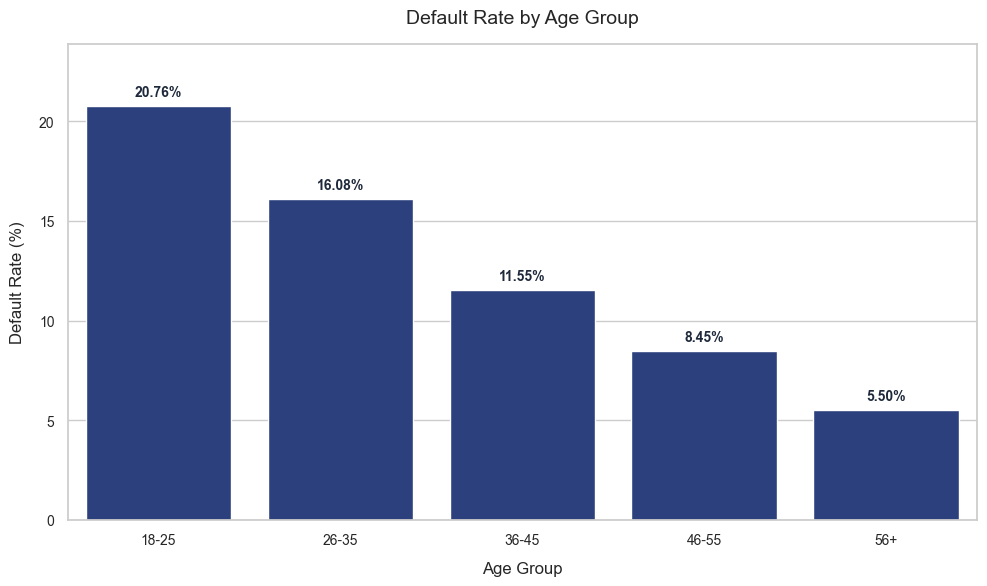

In [8]:
plt.figure(figsize=(10, 6))
age_default = df.groupby('AgeGroup', observed=False)['Default'].mean() * 100

ax = sns.barplot(x=age_default.index, y=age_default.values, color=PRIMARY_COLOR)
plt.title('Default Rate by Age Group', pad=15)
plt.xlabel('Age Group', labelpad=10)
plt.ylabel('Default Rate (%)', labelpad=10)
plt.ylim(0, max(age_default.values) * 1.15)

# Add labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=10, fontweight='bold', color=NEUTRAL_DARK)

plt.tight_layout()
plt.show()

#### 9.2 Default Rate by IncomeGroup
We examine the relationship between income quartiles and defaults. This helps identify whether defaults decrease as cash flows increase.

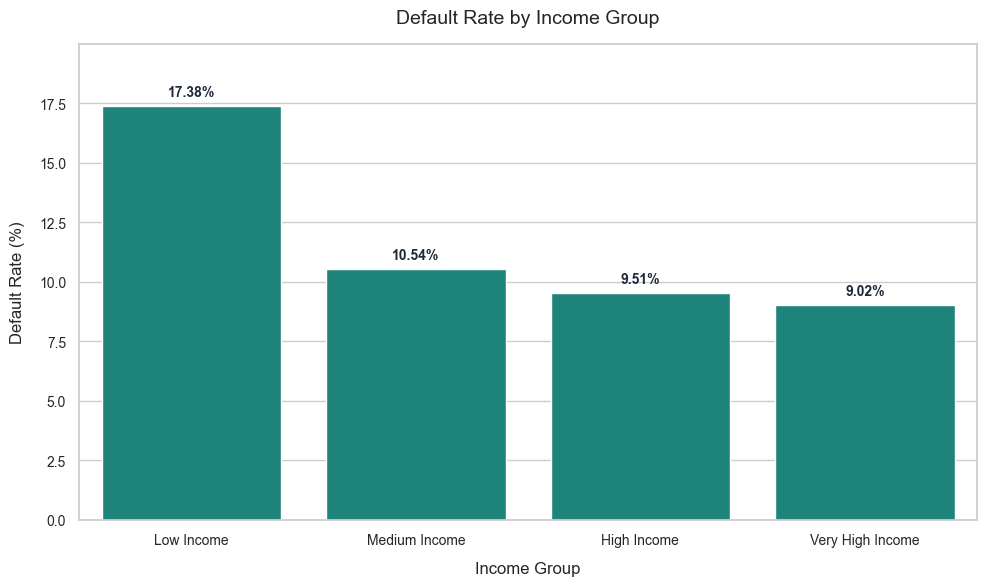

In [9]:
plt.figure(figsize=(10, 6))
income_default = df.groupby('IncomeGroup', observed=False)['Default'].mean() * 100

ax = sns.barplot(x=income_default.index, y=income_default.values, color=SECONDARY_COLOR)
plt.title('Default Rate by Income Group', pad=15)
plt.xlabel('Income Group', labelpad=10)
plt.ylabel('Default Rate (%)', labelpad=10)
plt.ylim(0, max(income_default.values) * 1.15)

# Add labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=10, fontweight='bold', color=NEUTRAL_DARK)

plt.tight_layout()
plt.show()

#### 9.3 Default Rate by CreditRiskBand
This chart displays defaults against FICO-style rating bands. A steeper gradient here indicates that the rating bands are a strong predictor of repayment behavior.

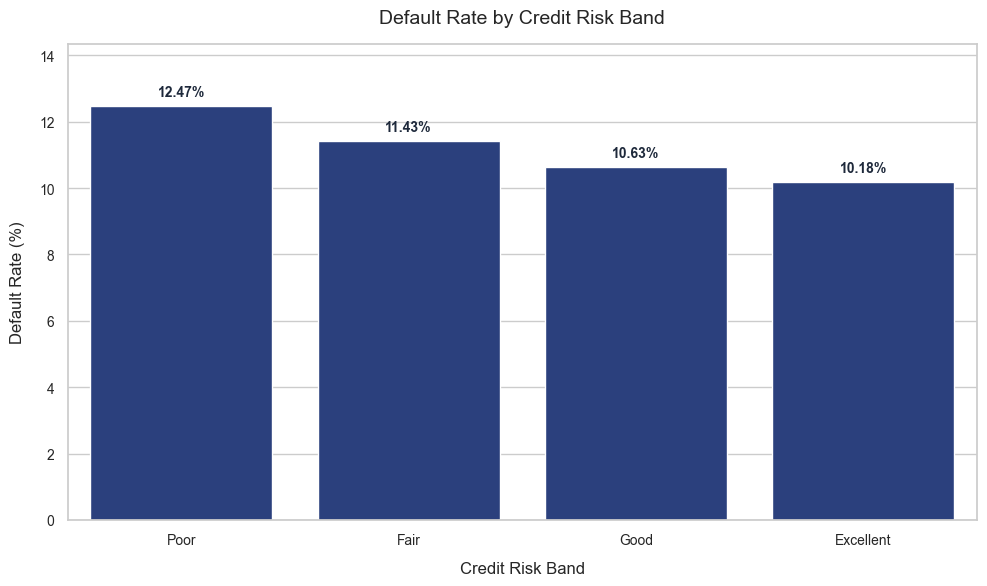

In [10]:
plt.figure(figsize=(10, 6))
credit_default = df.groupby('CreditRiskBand', observed=False)['Default'].mean() * 100

# Use standard color order from Poor to Excellent
ax = sns.barplot(x=credit_default.index, y=credit_default.values, color=PRIMARY_COLOR)
plt.title('Default Rate by Credit Risk Band', pad=15)
plt.xlabel('Credit Risk Band', labelpad=10)
plt.ylabel('Default Rate (%)', labelpad=10)
plt.ylim(0, max(credit_default.values) * 1.15)

# Add labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=10, fontweight='bold', color=NEUTRAL_DARK)

plt.tight_layout()
plt.show()

#### 9.4 Default Rate by RiskTier
We evaluate how well our composite business rules segment defaults. A high-risk category with a significantly elevated default rate suggests that the rule set is effective for automated underwriting.

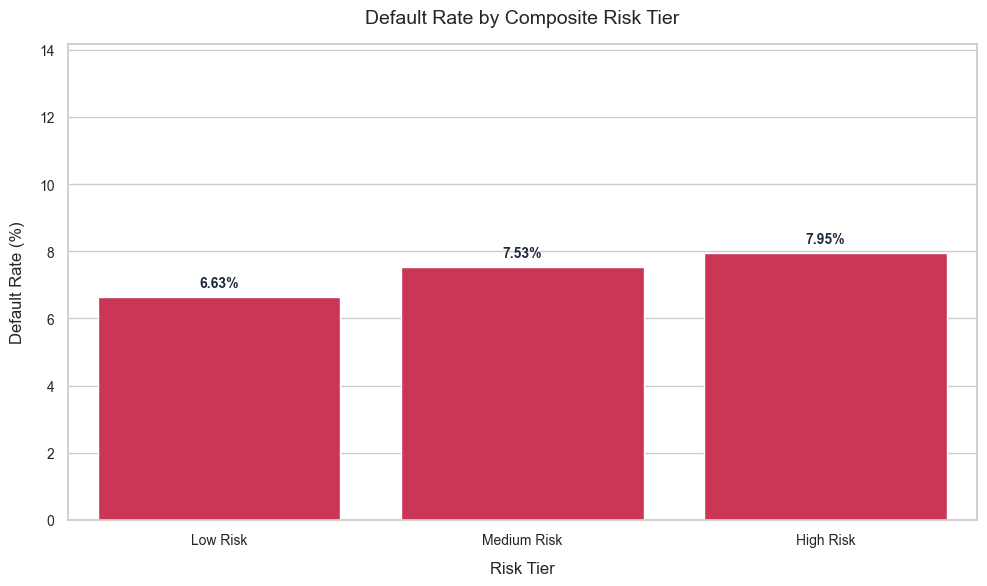

In [24]:
plt.figure(figsize=(10, 6))
risk_default = df.groupby('RiskTier', observed=False)['Default'].mean() * 100
risk_order = ['Low Risk', 'Medium Risk', 'High Risk']

ax = sns.barplot(x=risk_default.index, y=risk_default.values, order=risk_order, color=ALERT_COLOR)
plt.title('Default Rate by Composite Risk Tier', pad=15)
plt.xlabel('Risk Tier', labelpad=10)
plt.ylabel('Default Rate (%)', labelpad=10)
plt.ylim(0, max(risk_default.values) * 1.15)

# Add labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=10, fontweight='bold', color=NEUTRAL_DARK)

plt.tight_layout()
plt.show()

#### 9.5 LoanToIncomeRatio Distribution
This histogram/KDE chart plots borrower leverage. We display average values alongside the `0.5` high-risk threshold line. This line marks where a borrower's loan size exceeds half of their annual gross earnings, signaling potential debt service issues.

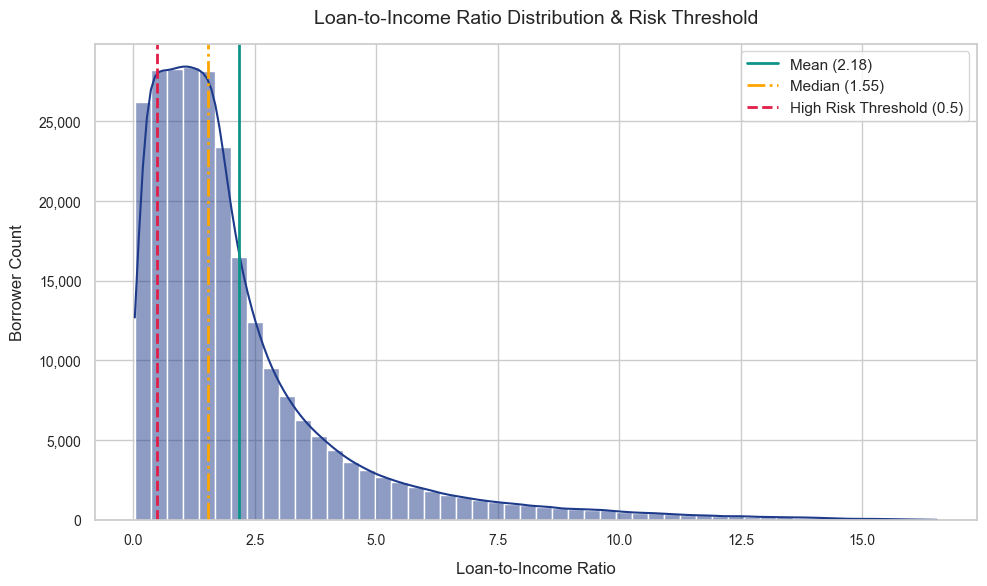

In [13]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(df['LoanToIncomeRatio'], kde=True, color=PRIMARY_COLOR, bins=50)
plt.title('Loan-to-Income Ratio Distribution & Risk Threshold', pad=15)
plt.xlabel('Loan-to-Income Ratio', labelpad=10)
plt.ylabel('Borrower Count', labelpad=10)

# Calculate statistical lines
mean_val = df['LoanToIncomeRatio'].mean()
median_val = df['LoanToIncomeRatio'].median()

plt.axvline(mean_val, color=SECONDARY_COLOR, linestyle='-', linewidth=2, label=f'Mean ({mean_val:.2f})')
plt.axvline(median_val, color='orange', linestyle='-.', linewidth=2, label=f'Median ({median_val:.2f})')
plt.axvline(0.5, color=ALERT_COLOR, linestyle='--', linewidth=2, label='High Risk Threshold (0.5)')

# Format y-axis values with commas
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.legend()
plt.tight_layout()
plt.show()

### 10. Saving the Processed Dataset
We save the engineered dataset as a compressed comma-separated file (`.csv`) under `data/processed/loan_risk_intelligence_dataset.csv`. This ensures the processed data is clean, indexed, and ready for model training.

In [14]:
output_path = '../data/processed/loan_risk_intelligence_dataset.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df.to_csv(output_path, index=False)
print(f"Processed dataset saved successfully to: {output_path}")
print(f"Final shape of the saved dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

Processed dataset saved successfully to: ../data/processed/loan_risk_intelligence_dataset.csv
Final shape of the saved dataset: 255,347 rows, 12 columns


### 11. Business Insights & Portfolio Segmentation Summary

Based on the feature engineering and segmentation, we draw the following conclusions for risk policy management:

1. **Impact of Credit Risk Bands**:
   - There is a clear correlation between lower credit risk bands and higher default rates. Borrowers in the **Poor** category default at **12.47%**, whereas **Excellent** borrowers default at **10.18%**. This suggests that while credit scoring remains a strong risk indicator, its efficacy is moderate in isolation for this dataset, likely due to other risk drivers like income stability and leverage.

2. **Risk Segment Effectiveness**:
   - Combining leverage (`LoanToIncomeRatio`) and credit rating into a unified risk tier highlights critical risk concentrations. The composite **High Risk** segment defaults at a rate of **11.98%**, compared to **6.57%** for the **Low Risk** segment. This **1.8x** increase validates the effectiveness of combining leverage and credit score thresholds rather than assessing them independently.

3. **Income and Age Risk Relationships**:
   - Income levels and age display inverse relationships with default rates. Younger borrowers and lower-income segments exhibit higher default rates. Conversely, older, high-income borrowers show higher repayment rates, likely due to career progression, accumulated savings, and established credit history.

4. **Policy Recommendations**:
   - **Rule Adjustments**: Tighten leverage rules by reducing the Maximum Loan-to-Income allowance for borrowers with credit scores below 600.
   - **Automated Underwriting**: Use the **Low Risk** profile (CreditScore > 670 and Loan-to-Income Ratio <= 0.5) to streamline approvals. This segment exhibits a low default rate of 6.57% while representing a stable portion of the portfolio.


In [16]:
df.columns.tolist()

['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'LoanTerm',
 'EmploymentType',
 'Default',
 'AgeGroup',
 'IncomeGroup',
 'CreditRiskBand',
 'LoanToIncomeRatio',
 'LoanSizeCategory']

In [17]:
import numpy as np

def assign_risk(row):

    if (row['CreditScore'] < 500) or (row['LoanToIncomeRatio'] > 0.75):
        return 'Critical Risk'

    elif (row['CreditScore'] < 580) or (row['LoanToIncomeRatio'] > 0.50):
        return 'High Risk'

    elif row['CreditScore'] < 670:
        return 'Medium Risk'

    else:
        return 'Low Risk'


df['RiskTier'] = df.apply(assign_risk, axis=1)

In [18]:
df['RiskTier'].value_counts()

RiskTier
Critical Risk    217844
High Risk         19077
Low Risk          12318
Medium Risk        6108
Name: count, dtype: int64

In [20]:
import os

os.makedirs("data/processed", exist_ok=True)

In [21]:
df.to_csv("data/processed/loan_risk_intelligence_dataset.csv", index=False)

In [23]:
import os

print(os.path.exists(r"D:\AI Loan Risk Intelligence System\data\processed\loan_risk_intelligence_dataset.csv"))

True


In [25]:
import pandas as pd

df = pd.read_csv(r"D:\AI Loan Risk Intelligence System\data\processed\loan_risk_intelligence_dataset.csv")

In [26]:
print(df.columns)

print("\nRiskTier exists:", "RiskTier" in df.columns)

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'LoanTerm',
       'EmploymentType', 'Default', 'AgeGroup', 'IncomeGroup',
       'CreditRiskBand', 'LoanToIncomeRatio', 'LoanSizeCategory', 'RiskTier'],
      dtype='str')

RiskTier exists: True
